#### Import

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from tqdm import tqdm
from functions_utils import *
from functions_data import *
from functions_optimize import *
from functions_eval import *

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
S, R, P_RT, K, K0, M1, M2 = load_parameters(I, T, generation_data)
P_DA, P_PN = load_price_data()

✅ 총 5개 파일을 불러왔습니다: 1201.csv, 137.csv, 401.csv, 524.csv, 89.csv
📊 데이터 Shape: I=5, T=24, S=20
✅ 시뮬레이션 초기화 완료: S=20, Randomness='high', M1=757.00, M2=2111.00


#### Preliminaries

In [2]:
print("[Individual Participation Model optimization]")
x_ind, yp_ind, ym_ind, z_ind, zc_ind, zd_ind, obj_ind = optimize_individually_forall(R, K, K0, P_DA, P_RT, P_PN, I, T, S, M1)
print("-"*100)

print("[Holistic Aggregation Model optimization]")
x_hol, a_hol, yp_hol, ym_hol, z_hol, zc_hol, zd_hol, ep_hol, bp_hol, em_hol, bm_hol, d_hol, dp_hol, dm_hol, obj_hol = optimize_hol(R, K, K0, P_DA, P_RT, P_PN, I, T, S, M1, M2)
print("-"*100)

print("[Extracting target_i from Holistic Aggregation Model]")
x_extracted, ep_extracted, em_extracted, yp_extracted, ym_extracted, d_extracted, dp_extracted, dm_extracted, i_map_extracted = extracted_target(I, T, S, x_hol, ep_hol, em_hol, yp_hol, ym_hol, d_hol, dp_hol, dm_hol)
print("-"*100)

print("[Holistic Aggregation Model optimization without target_i]")
x_without, ep_without, em_without, yp_without, ym_without, d_without, dp_without, dm_without, i_map_without = optimize_without_loop(R, K, K0, P_DA, P_RT, P_PN, I, T, S)
print("-"*100)

[Individual Participation Model optimization]


Optimizing individually for each target_i:   0%|          | 0/5 [00:00<?, ?it/s]

Set parameter Username
Set parameter LicenseID to value 2611964
Academic license - for non-commercial use only - expires 2026-01-20
Set parameter MIPGap to value 1e-07


Optimizing individually for each target_i:  20%|██        | 1/5 [00:00<00:00,  7.58it/s]

Optimal solution found for target_i=0! Objective value: 217787.0598190179
Set parameter MIPGap to value 1e-07


...

Set parameter MIPGap to value 1e-07


Solving settlement model for each target DER:  80%|████████  | 4/5 [00:22<00:05,  5.07s/it]

Set parameter MIPGap to value 1e-07


Solving settlement model for each target DER: 100%|██████████| 5/5 [00:28<00:00,  5.74s/it]

----------------------------------------------------------------------------------------------------


#### Price Functions

In [3]:
RP = np.full((I, T, S, 2), np.nan, dtype=object)
RM = np.full((I, T, S, 2), np.nan, dtype=object)
BP = np.zeros((I, T, S), dtype=int)
BM = np.zeros((I, T, S), dtype=int)
BIG_POS = 1e10; BIG_NEG = -1e10

for target_i, t, s in product(range(I), range(T), range(S)):
    if dp_hol[target_i, t, s] > 0:
        RP[target_i, t, s] = [
            [0, P_PN[t] - P_RT[t, s]],
            [dp_hol[target_i, t, s], BIG_NEG]
        ]
        BP[target_i, t, s] = 2

        RM[target_i, t, s] = [
            [1, BIG_POS]
        ]
        BM[target_i, t, s] = 1

    elif dm_hol[target_i, t, s] > 0:
        RP[target_i, t, s] = [
            [1, BIG_NEG]
        ]
        BP[target_i, t, s] = 1

        RM[target_i, t, s] = [
            [0, P_PN[t] - P_RT[t, s]],
            [dm_hol[target_i, t, s], BIG_POS]
        ]
        BM[target_i, t, s] = 2

    else:
        RP[target_i, t, s] = [
            [0, BIG_NEG]
        ]
        BP[target_i, t, s] = 1

        RM[target_i, t, s] = [
            [0, BIG_POS]
        ]
        BM[target_i, t, s] = 1

In [4]:
for target_i, t, s in product(range(I), range(20,21), range(8,9)):
    print(f"[{target_i}, {t}, {s}]")
    print(f"ρ⁺(d) = ({dp_hol[target_i, t, s]}, {RP[target_i, t, s, 0][1]})")
    print(f"ρ⁻(d) = ({dm_hol[target_i, t, s]}, {RM[target_i, t, s, 0][1]})")
    print()

[0, 20, 8]
ρ⁺(d) = (0.0, -10000000000.0)
ρ⁻(d) = (69.0, 56.79810544513194)

[1, 20, 8]
ρ⁺(d) = (0.0, -10000000000.0)
ρ⁻(d) = (2.0, 56.79810544513194)

[2, 20, 8]
ρ⁺(d) = (13.0, 56.79810544513194)
ρ⁻(d) = (0.0, 10000000000.0)

[3, 20, 8]
ρ⁺(d) = (53.0, 56.79810544513194)
ρ⁻(d) = (0.0, 10000000000.0)

[4, 20, 8]
ρ⁺(d) = (5.0, 56.79810544513194)
ρ⁻(d) = (0.0, 10000000000.0)



In [5]:
total_demand_without = np.zeros((I, T, S))
total_supply_without = np.zeros((I, T, S))

for target_i, t, s in product(range(I), range(T), range(S)):
    total_supply_without[target_i, t, s] = sum(yp_without[target_i][i_map_without[target_i][i], t, s] for i in i_map_without[target_i])
    total_demand_without[target_i, t, s] = sum(ym_without[target_i][i_map_without[target_i][i], t, s] for i in i_map_without[target_i])

# RP, RM, BP, BM = transform_step(rho_plus, rho_minus, total_demand_without, total_supply_without, step_width_multiplier=1)

# print(yp_without[target_i][:, t, s])
# print(BP[target_i, t, s])
# print(RP[target_i, t, s])

# print(ym_without[target_i][:, t, s])
# print(BM[target_i, t, s])
# print(RM[target_i, t, s])

#### Stepwise Model

In [6]:
x_part, yp_part, ym_part, z_part, zc_part, zd_part, dp_part, dm_part, up_part, um_part, wp_part, wm_part, obj_part = [], [], [], [], [], [], [], [], [], [], [], [], []

for target_i in tqdm(range(I), desc="Optimizing Stepwise for each target_i"):
    model = gp.Model(f"Stepwise_Internal_Optimization_{target_i}")
    model.setParam("OutputFlag", 0)
    model.setParam("MIPGap", 1e-7)

    x = model.addVars(T, vtype=GRB.CONTINUOUS, lb=0, name="x")
    yp = model.addVars(T, S, vtype=GRB.CONTINUOUS, lb=0, name="y_plus")
    ym = model.addVars(T, S, vtype=GRB.CONTINUOUS, lb=0, name="y_minus")
    z = model.addVars(T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
    zc = model.addVars(T, S, vtype=GRB.CONTINUOUS, lb=0, name="z_charge")
    zd = model.addVars(T, S, vtype=GRB.CONTINUOUS, lb=0, name="z_discharge")
    dp = model.addVars(T, S, vtype=GRB.CONTINUOUS, lb=0, name="d_plus")
    dm = model.addVars(T, S, vtype=GRB.CONTINUOUS, lb=0, name="d_minus")

    p1 = model.addVars(T, S, vtype=GRB.BINARY, name="p1")
    p2 = model.addVars(T, S, vtype=GRB.BINARY, name="p2")
    p3 = model.addVars(T, S, vtype=GRB.BINARY, name="p3")
    p4 = model.addVars(T, S, vtype=GRB.BINARY, name="p4")
    
    wp, up = {}, {}
    wm, um = {}, {}
    for t, s in product(range(T), range(S)):
        Bp = BP[target_i, t, s]
        Bm = BM[target_i, t, s]
        for b in range(Bp):
            wp[t, s, b] = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name=f"w_plus_{t}_{s}_{b}")
            up[t, s, b] = model.addVar(vtype=GRB.BINARY, name=f"u_plus_{t}_{s}_{b}")
        for b in range(Bm):
            wm[t, s, b] = model.addVar(vtype=GRB.CONTINUOUS, lb=0, name=f"w_minus_{t}_{s}_{b}")
            um[t, s, b] = model.addVar(vtype=GRB.BINARY, name=f"u_minus_{t}_{s}_{b}")

    model.update()

    obj = gp.quicksum(P_DA[t] * x[t] for t in range(T)) \
        + gp.quicksum((1/S) * (P_RT[t, s] * yp[t, s] - P_PN[t] * ym[t, s]) for t in range(T) for s in range(S)) \
        + gp.quicksum((1/S) * (
            gp.quicksum(
                RP[target_i, t, s][b][1] * (wp[t, s, b] + up[t, s, b] * RP[target_i, t, s][b][0])
                for b in range(BP[target_i, t, s])
            ) -
            gp.quicksum(
                RM[target_i, t, s][b][1] * (wm[t, s, b] + um[t, s, b] * RM[target_i, t, s][b][0])
                for b in range(BM[target_i, t, s])
            )
        ) for t in range(T) for s in range(S))

    model.setObjective(obj, GRB.MAXIMIZE)

    for t, s in product(range(T), range(S)):
        model.addConstr(R[target_i, t, s] - x[t] == yp[t, s] - ym[t, s] + zc[t, s] - zd[t, s] + dp[t, s] - dm[t, s])
        model.addConstr(yp[t, s] + dp[t, s] + zc[t, s] <= R[target_i, t, s] + zd[t, s])
        model.addConstr(z[t + 1, s] == z[t, s] + zc[t, s] - zd[t, s])
        model.addConstr(zd[t, s] <= z[t, s])
        model.addConstr(zc[t, s] <= K[target_i] - z[t, s])
        model.addConstr(z[t, s] <= K[target_i])
        model.addConstr(z[t, s] >= 0)
        model.addConstr(yp[t, s] <= M1 * p1[t, s])
        model.addConstr(ym[t, s] <= M1 * (1 - p1[t, s]))
        model.addConstr(ym[t, s] <= M1 * p2[t, s])
        model.addConstr(zc[t, s] <= M1 * (1 - p2[t, s]))
        model.addConstr(zc[t, s] <= M1 * p3[t, s])
        model.addConstr(zd[t, s] <= M1 * (1 - p3[t, s]))
        model.addConstr(dp[t, s] <= M1 * p4[t, s])
        model.addConstr(dm[t, s] <= M1 * (1 - p4[t, s]))

    for s in range(S):
        model.addConstr(z[0, s] == K0[target_i])

    for t, s in product(range(T), range(S)):
        model.addConstr(dp[t, s] == gp.quicksum(wp[t, s, bp] + up[t, s, bp] * RP[target_i, t, s][bp][0]
                                                for bp in range(BP[target_i, t, s])))
        model.addConstr(dm[t, s] == gp.quicksum(wm[t, s, bm] + um[t, s, bm] * RM[target_i, t, s][bm][0]
                                                for bm in range(BM[target_i, t, s])))

        model.addConstr(gp.quicksum(up[t, s, bp] for bp in range(BP[target_i, t, s])) <= 1)
        model.addConstr(gp.quicksum(um[t, s, bm] for bm in range(BM[target_i, t, s])) <= 1)
            
        for bp in range(BP[target_i, t, s]):
            if bp < BP[target_i, t, s] - 1:
                WIDTH = RP[target_i, t, s][bp + 1][0] - RP[target_i, t, s][bp][0]
            else:
                WIDTH = max(1e-6, total_demand_without[target_i, t, s] - RP[target_i, t, s][bp][0])
            model.addConstr(wp[t, s, bp] <= up[t, s, bp] * WIDTH)

        for bm in range(BM[target_i, t, s]):
            if bm < BM[target_i, t, s] - 1:
                WIDTH = RM[target_i, t, s][bm + 1][0] - RM[target_i, t, s][bm][0]
            else:
                WIDTH = max(1e-6, total_supply_without[target_i, t, s] - RM[target_i, t, s][bm][0])
            model.addConstr(wm[t, s, bm] <= um[t, s, bm] * WIDTH)

    model.optimize()

    x_part.append(np.array([x[t].X for t in range(T)]))
    yp_part.append(np.array([[yp[t, s].X for s in range(S)] for t in range(T)]))
    ym_part.append(np.array([[ym[t, s].X for s in range(S)] for t in range(T)]))
    z_part.append(np.array([[z[t, s].X for s in range(S)] for t in range(T + 1)]))
    zc_part.append(np.array([[zc[t, s].X for s in range(S)] for t in range(T)]))
    zd_part.append(np.array([[zd[t, s].X for s in range(S)] for t in range(T)]))
    dp_part.append(np.array([[dp[t, s].X for s in range(S)] for t in range(T)]))
    dm_part.append(np.array([[dm[t, s].X for s in range(S)] for t in range(T)]))
    obj_part.append(model.objVal)
    
    MAX_BP = np.max(BP[target_i])
    MAX_BM = np.max(BM[target_i])

    up_array = np.full((T, S, MAX_BP), np.nan)
    um_array = np.full((T, S, MAX_BM), np.nan)
    wp_array = np.full((T, S, MAX_BP), np.nan)
    wm_array = np.full((T, S, MAX_BM), np.nan)

    for t, s in product(range(T), range(S)):
        for bp in range(BP[target_i, t, s]):
            up_array[t, s, bp] = up[t, s, bp].X
            wp_array[t, s, bp] = wp[t, s, bp].X
        for bm in range(BM[target_i, t, s]):
            um_array[t, s, bm] = um[t, s, bm].X
            wm_array[t, s, bm] = wm[t, s, bm].X

    up_part.append(up_array)
    um_part.append(um_array)
    wp_part.append(wp_array)
    wm_part.append(wm_array)

Optimizing Stepwise for each target_i: 100%|██████████| 5/5 [00:01<00:00,  4.94it/s]


In [7]:
RP_CLEARED = np.full((I, T, S), np.nan)
RM_CLEARED = np.full((I, T, S), np.nan)

for target_i in range(I):
    for s, t in product(range(S), range(T)):
        # RP_CLEARED 계산
        rp_found = False
        for bp in range(BP[target_i, t, s]):
            if round(up_part[target_i][t, s, bp]) == 1:
                RP_CLEARED[target_i, t, s] = RP[target_i, t, s][bp][1]
                rp_found = True
                break
        if not rp_found:
            RP_CLEARED[target_i, t, s] = BIG_NEG

        # RM_CLEARED 계산
        rm_found = False
        for bm in range(BM[target_i, t, s]):
            if round(um_part[target_i][t, s, bm]) == 1:
                RM_CLEARED[target_i, t, s] = RM[target_i, t, s][bm][1]
                rm_found = True
                break
        if not rm_found:
            RM_CLEARED[target_i, t, s] = BIG_POS

In [8]:
BEST_CASE_PROFIT = calculate_total_profit_best_case(x_part, yp_part, ym_part, dp_part, dm_part, dp_extracted, dm_extracted, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
WORST_CASE_PROFIT = calculate_total_profit_worst_case(x_part, yp_part, ym_part, dp_part, dm_part, dp_extracted, dm_extracted, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
NO_VIRTUAL_PRICE_PROFIT = calculate_total_profit_no_virtual_price(x_part, yp_part, ym_part, dp_part, dm_part, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)

print(BEST_CASE_PROFIT)
print(WORST_CASE_PROFIT)
print(NO_VIRTUAL_PRICE_PROFIT)

[261838.79139121 378947.68388224 439524.63451895 520584.97458089
 197483.62312851]
[261838.79139121 378947.68388224 439524.63451895 520584.97455747
 197483.62312851]
[212123.7071278  371694.53690289 388678.35455457 500883.96803667
 193787.20440726]


#### Results

In [64]:
target_i = 0

header = (
    f"{'s':>2} {'t':>2} | "
    f"{'R':>8} {'x':>8} {'y+':>8} {'y-':>8} "
    f"{'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n"
    + "-" * 90
)
# print(header)

for s, t in product(range(0,1), range(T)):
    print(header)
    print(
        f"{s:>2} {t:>2} | "
        f"{R[target_i, t, s]:>8.2f} {x_part[target_i][t]:>8.2f} {yp_part[target_i][t, s]:>8.2f} {ym_part[target_i][t, s]:>8.2f} "
        f"{dp_part[target_i][t, s]:>8.2f} {dm_part[target_i][t, s]:>8.2f} {zc_part[target_i][t, s]:>8.2f} {zd_part[target_i][t, s]:>8.2f} {z_part[target_i][t, s]:>8.2f}"
    )
    print(
        f"{s:>2} {t:>2} | "
        f"{R[target_i, t, s]:>8.2f} {x_hol[target_i, t]:>8.2f} {ep_hol[target_i, t, s]:>8.2f} {em_hol[target_i, t, s]:>8.2f} "
        f"{dp_hol[target_i, t, s]:>8.2f} {dm_hol[target_i, t, s]:>8.2f} {zc_hol[target_i, t, s]:>8.2f} {zd_hol[target_i, t, s]:>8.2f} {z_hol[target_i, t, s]:>8.2f}"
    )
    print()

 s  t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0  0 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  0 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00

 s  t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0  1 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  1 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00

 s  t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0  2 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 0  2 |     0

In [61]:
for target_i, s, t in product(range(0,1), range(S), range(9,T)):
    print(f"[i={target_i}, t={t}, s={s}] dp_hol = {dp_hol[target_i, t, s]}")
    for b in range(1):
        print(f"up = {up_part[target_i][t, s, b]}")
        print(f"wp = {wp_part[target_i][t, s, b]}")
    print()
    # print(f"[i={target_i}, t={t}, s={s}] dm_hol = {dm_hol[target_i, t, s]}")
    # for b in range(1):
    #     print(f"um[i={target_i}][t={t}][s={s}][b={b}] = {um_part[target_i][t, s, b]}")
    #     print(f"wm[i={target_i}][t={t}][s={s}][b={b}] = {wm_part[target_i][t, s, b]}")
    # print()


[i=0, t=9, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=10, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=11, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=12, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=13, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=14, s=0] dp_hol = 217.0
up = 1.0
wp = 0.0

[i=0, t=15, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=16, s=0] dp_hol = 0.0
up = -0.0
wp = 0.0

[i=0, t=17, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=18, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=19, s=0] dp_hol = 51.0
up = 1.0
wp = 0.0

[i=0, t=20, s=0] dp_hol = 0.0
up = -0.0
wp = 0.0

[i=0, t=21, s=0] dp_hol = 3.0
up = 1.0
wp = 0.0

[i=0, t=22, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=23, s=0] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=9, s=1] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=10, s=1] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=11, s=1] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=12, s=1] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=13, s=1] dp_hol = 0.0
up = 1.0
wp = 0.0

[i=0, t=14, s=1] 

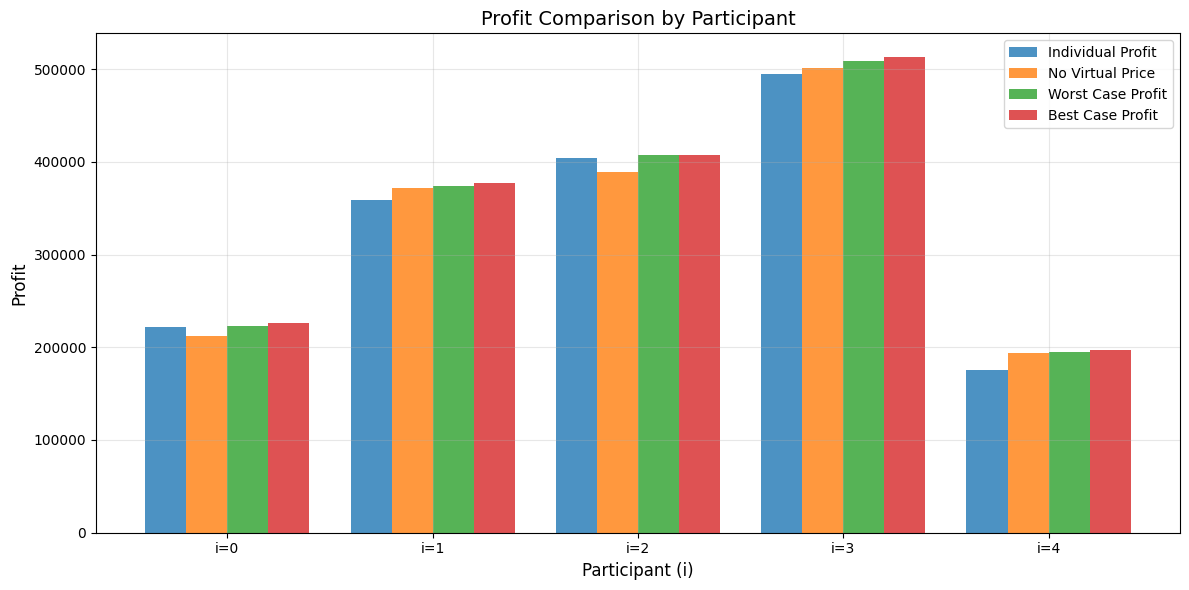

In [65]:
evaluate_and_visualize_profits(x_ind, yp_ind, ym_ind, P_DA, P_RT, P_PN, NO_VIRTUAL_PRICE_PROFIT, WORST_CASE_PROFIT, BEST_CASE_PROFIT, T, S, I)


In [12]:
compare_step_vs_ind(x_part, yp_part, ym_part, dp_part, dm_part, x_ind, yp_ind, ym_ind, RP_CLEARED, RM_CLEARED, P_DA, P_RT, P_PN, T, S, I)
print_summary_only(x_part, yp_part, ym_part, dp_part, dm_part, x_ind, yp_ind, ym_ind, T, S, I)


타겟 참여자 0번의 시간대별 입찰량 비교 (시나리오 평균):
-------------------------------------------------------------------------------------------------------------------------------------------------
  t |     P_DA   x_step    x_ind ||           RHO_P  dp_step     P_RT  yp_step   yp_ind ||           RHO_M  dm_step     P_PN  ym_step   ym_ind
-------------------------------------------------------------------------------------------------------------------------------------------------
  0 |    99.10     0.00     0.00 || -10000000000.00     0.00    59.92     0.00     0.00 ||  10000000000.00     0.00   148.65     0.00     0.00
  1 |    86.48     0.00     0.00 || -10000000000.00     0.00    93.63     0.00     0.00 ||  10000000000.00     0.00   129.71     0.00     0.00
  2 |    79.89     0.00     0.00 || -10000000000.00     0.00    69.33     0.00     0.00 ||  10000000000.00     0.00   119.83     0.00     0.00
  3 |    77.04     0.00     0.00 || -10000000000.00     0.00    74.57     0.00     0.00 ||  100000000

In [ ]:
compare_step_vs_hol(x_hol, ep_hol, em_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, T, S, I)

STEPWISE vs HOLISTIC 모델 비교 (시나리오 평균)

타겟 참여자 0번:
------------------------------------------------------------------------------------------------------------------------
 t |   x_step    x_hol |  yp_step   yp_hol |  dp_step   dp_hol |  ym_step   ym_hol |  dm_step   dm_hol
------------------------------------------------------------------------------------------------------------------------
 0 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00
 1 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00
 2 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00
 3 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00
 4 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00
 5 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.00     0.00 |     0.

In [66]:
calculate_aggregated_profit_evaluation(x_ind, yp_ind, ym_ind, NO_VIRTUAL_PRICE_PROFIT, WORST_CASE_PROFIT, BEST_CASE_PROFIT, a_hol, bp_hol, bm_hol, P_DA, P_RT, P_PN, T, S, I)

                          Profit Type      Profit
0                   Individual Profit 1655568.681
1  Stepwise Profit (No Virtual Price) 1667167.771
2        Stepwise Profit (Worst Case) 1706254.973
3         Stepwise Profit (Best Case) 1721052.750
4                  Aggregation Profit 1783740.243


In [ ]:
compare_holall_vs_holwithstep(x_hol, ep_hol, em_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, T, S, I)

전체 holistic 최적화 vs 본인만 stepwise 최적화 + 나머지는 (본인포함) holistic
 i |  t |  x_hol_sum   x_part_sum |  ep_hol_mean  yp_part_sum |  em_hol_mean  ym_part_sum |  dp_hol_mean  dp_part_sum |  dm_hol_mean  dm_part_sum
------------------------------------------------------------------------------------------------------------------------
 0 |  0 |       0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 0 |  1 |       0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 0 |  2 |       0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 0 |  3 |       0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 0 |  4 |       0.00         0.00 |         0.00         0.00 |         0.00         0.00 

In [16]:
compare_holall_vs_stepsum(a_hol, bp_hol, bm_hol, dp_hol, dm_hol, x_part, yp_part, ym_part, dp_part, dm_part, T, S, I)

시간별 시나리오 평균 비교
--------------------------------------------------------------------------------------------------------------------------------------------
 t |    a_hol   x_part_sum |   bp_hol_avg  yp_part_sum |   bm_hol_avg  ym_part_sum |   dp_hol_sum  dp_part_sum |   dm_hol_sum  dm_part_sum
--------------------------------------------------------------------------------------------------------------------------------------------
 0 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 1 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 2 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 3 |     0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00 |         0.00         0.00
 4 |    